# Smart City Traffic Forecasting
Load data, preprocess, train Random Forest.

In [2]:
# ============================
# Import Required Libraries
# ============================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

plt.style.use("ggplot")


In [3]:
# ============================
# Load Dataset
# ============================

train = pd.read_csv("train_aWnotuB.csv")
test = pd.read_csv("test_BdBKkAj.csv")

In [4]:
# First Five Rows

train.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [5]:
# Dataset Information

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   DateTime  48120 non-null  str  
 1   Junction  48120 non-null  int64
 2   Vehicles  48120 non-null  int64
 3   ID        48120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


In [6]:
# Shape

print("Training Shape :", train.shape)
print("Testing Shape :", test.shape)

Training Shape : (48120, 4)
Testing Shape : (11808, 3)


In [7]:
# Missing Values

train.isnull().sum()

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

In [8]:
# Statistical Summary

train.describe()

,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [9]:
# ============================
# Convert DateTime
# ============================

train["DateTime"] = pd.to_datetime(train["DateTime"])
test["DateTime"] = pd.to_datetime(test["DateTime"])

In [10]:
# ============================
# Feature Engineering
# ============================

train["Year"] = train["DateTime"].dt.year
train["Month"] = train["DateTime"].dt.month
train["Day"] = train["DateTime"].dt.day
train["Hour"] = train["DateTime"].dt.hour
train["DayOfWeek"] = train["DateTime"].dt.dayofweek

test["Year"] = test["DateTime"].dt.year
test["Month"] = test["DateTime"].dt.month
test["Day"] = test["DateTime"].dt.day
test["Hour"] = test["DateTime"].dt.hour
test["DayOfWeek"] = test["DateTime"].dt.dayofweek

In [11]:
# Check Dataset

train.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,6
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,6
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,6
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,6
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,6


In [12]:
# New Columns

train.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID', 'Year', 'Month', 'Day',
       'Hour', 'DayOfWeek'],
      dtype='str')

In [13]:
# ============================
# Remove Unnecessary Columns
# ============================

X = train.drop(["DateTime", "Vehicles", "ID"], axis=1)
y = train["Vehicles"]

In [14]:
X.head()

,Junction,Year,Month,Day,Hour,DayOfWeek
0,1,2015,11,1,0,6
1,1,2015,11,1,1,6
2,1,2015,11,1,2,6
3,1,2015,11,1,3,6
4,1,2015,11,1,4,6


In [15]:
print(X.shape)
print(y.shape)

(48120, 6)
(48120,)


# Exploratory Data Analysis (EDA)

# Vehicle Distribution


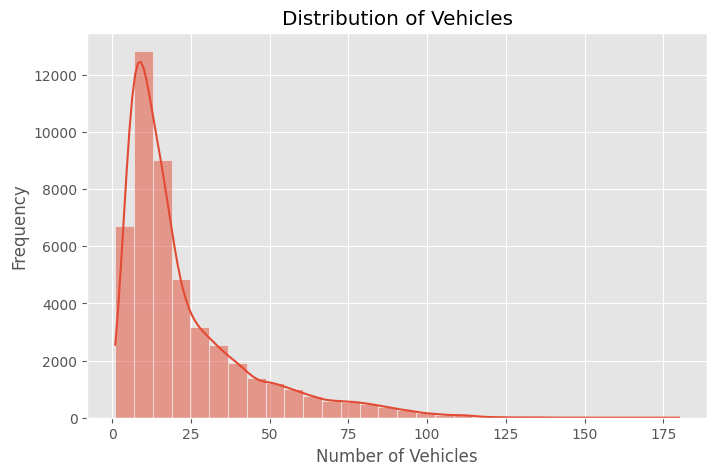

In [16]:
# ==========================================
# Exploratory Data Analysis (EDA)
# Vehicle Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(train["Vehicles"], bins=30, kde=True)

plt.title("Distribution of Vehicles")

plt.xlabel("Number of Vehicles")

plt.ylabel("Frequency")

plt.show()

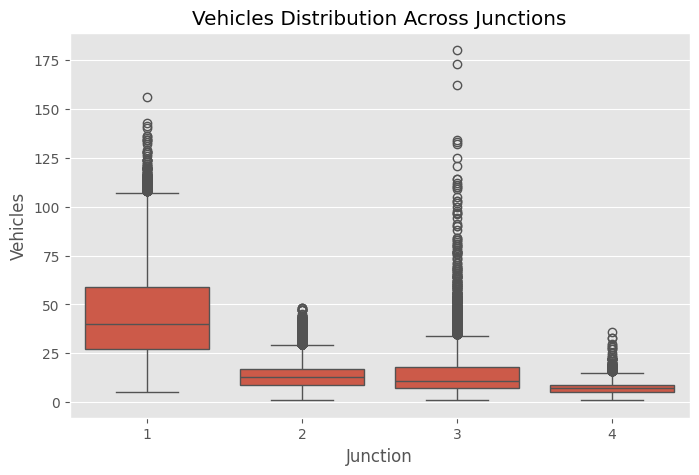

In [17]:
# ==========================================
# Vehicles Count by Junction
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(x="Junction", y="Vehicles", data=train)

plt.title("Vehicles Distribution Across Junctions")

plt.show()

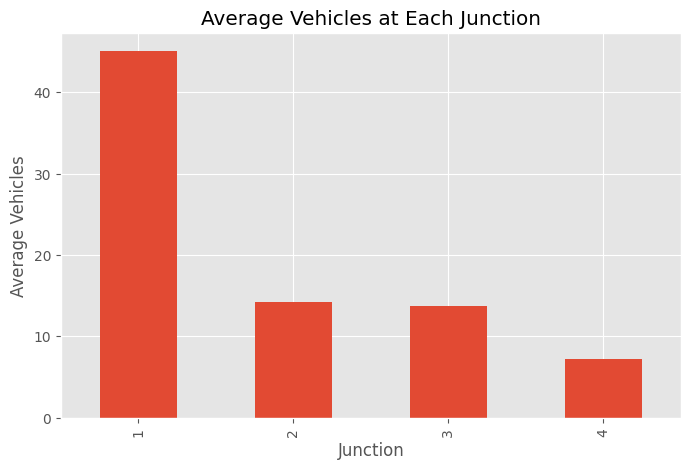

In [18]:
# ==========================================
# Average Traffic at Each Junction
# ==========================================

plt.figure(figsize=(8,5))

train.groupby("Junction")["Vehicles"].mean().plot(kind="bar")

plt.title("Average Vehicles at Each Junction")

plt.xlabel("Junction")

plt.ylabel("Average Vehicles")

plt.show()

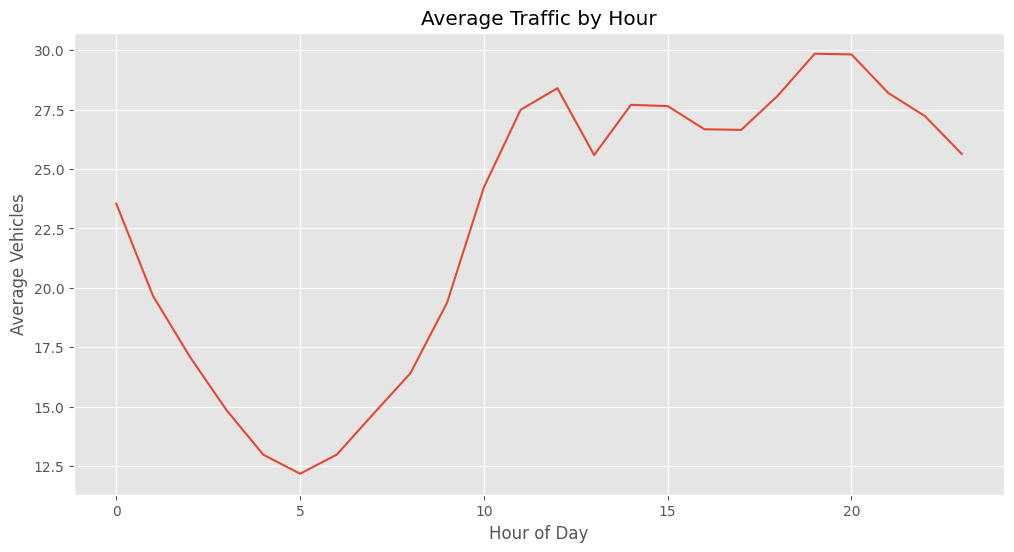

In [19]:
# ==========================================
# Traffic by Hour
# ==========================================

plt.figure(figsize=(12,6))

train.groupby("Hour")["Vehicles"].mean().plot()

plt.title("Average Traffic by Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Average Vehicles")

plt.grid(True)

plt.show()

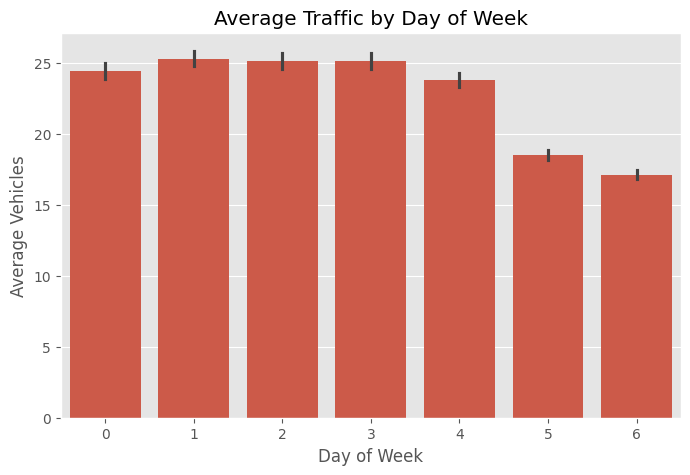

In [20]:
# ==========================================
# Traffic by Day of Week
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    x="DayOfWeek",
    y="Vehicles",
    data=train,
    estimator=np.mean
)

plt.title("Average Traffic by Day of Week")

plt.xlabel("Day of Week")

plt.ylabel("Average Vehicles")

plt.show()

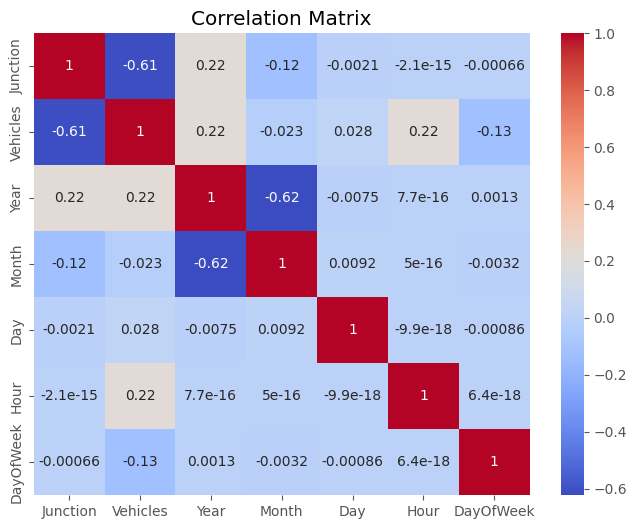

In [21]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    train.drop(["DateTime","ID"], axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

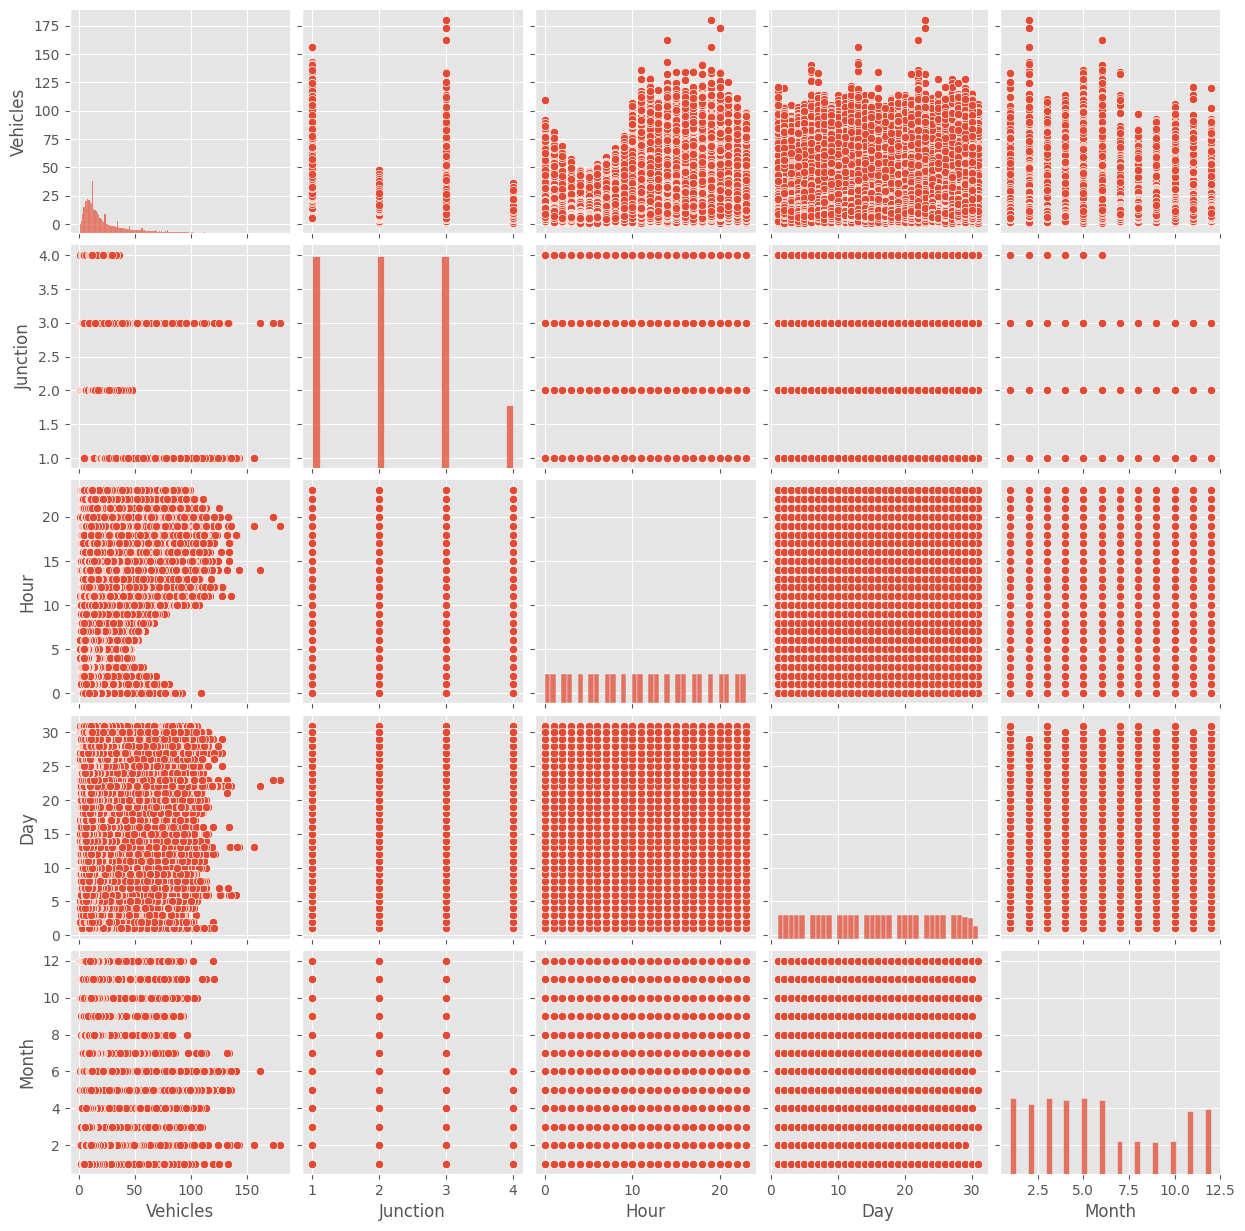

In [22]:
# ==========================================
# Pair Plot
# ==========================================

sns.pairplot(
    train[["Vehicles","Junction","Hour","Day","Month"]]
)

plt.show()

# Model Building

In [23]:
# ==========================================
# Train Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (38496, 6)
Testing Data : (9624, 6)


In [24]:
# ==========================================
# Linear Regression Model
# ==========================================

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression Model Created Successfully")

Linear Regression Model Created Successfully


In [25]:
# ==========================================
# Linear Regression Evaluation
# ==========================================

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("--------------------------")
print("MAE :", lr_mae)
print("RMSE :", lr_rmse)
print("R2 Score :", lr_r2)

Linear Regression Results
--------------------------
MAE : 9.63767609602981
RMSE : 12.772033686569724
R2 Score : 0.5997395466492281


In [26]:
# ==========================================
# Decision Tree Regression
# ==========================================

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Model Created Successfully")

Decision Tree Model Created Successfully


In [27]:
# ==========================================
# Decision Tree Evaluation
# ==========================================

dt_mae = mean_absolute_error(y_test, dt_pred)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("--------------------------")
print("MAE :", dt_mae)
print("RMSE :", dt_rmse)
print("R2 Score :", dt_r2)

Decision Tree Results
--------------------------
MAE : 3.136118038237739
RMSE : 4.794032900877568
R2 Score : 0.943607078705784


In [28]:
# ==========================================
# Random Forest Regression
# ==========================================

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Model Created Successfully")

Random Forest Model Created Successfully


In [29]:
# ==========================================
# Random Forest Evaluation
# ==========================================

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("--------------------------")
print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R2 Score :", rf_r2)

Random Forest Results
--------------------------
MAE : 2.393583748960931
RMSE : 3.557033320803083
R2 Score : 0.9689545156881921


In [30]:
# ==========================================
# Model Comparison
# ==========================================

comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        lr_mae,
        dt_mae,
        rf_mae
    ],

    "RMSE":[
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],

    "R2 Score":[
        lr_r2,
        dt_r2,
        rf_r2
    ]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.637676,12.772034,0.599740
1,Decision Tree,3.136118,4.794033,0.943607
2,Random Forest,2.393584,3.557033,0.968955


In [31]:
# ==========================================
# Best Model
# ==========================================

comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,2.393584,3.557033,0.968955
1,Decision Tree,3.136118,4.794033,0.943607
0,Linear Regression,9.637676,12.772034,0.599740


# Prediction on Test Dataset

In [32]:
# ==========================================
# Prepare Test Dataset
# ==========================================

test_features = test.copy()

test_features = test_features.drop(["DateTime", "ID"], axis=1)

test_features.head()

,Junction,Year,Month,Day,Hour,DayOfWeek
0,1,2017,7,1,0,5
1,1,2017,7,1,1,5
2,1,2017,7,1,2,5
3,1,2017,7,1,3,5
4,1,2017,7,1,4,5


In [33]:
# ==========================================
# Predict Traffic
# ==========================================

traffic_prediction = rf.predict(test_features)

traffic_prediction[:10]

array([66.665, 60.55 , 43.135, 37.97 , 32.12 , 30.63 , 30.665, 32.29 ,
       37.76 , 42.915])

In [34]:
# ==========================================
# Add Prediction Column
# ==========================================

submission = test.copy()

submission["Predicted_Vehicles"] = traffic_prediction

submission.head()

,DateTime,Junction,ID,Year,Month,Day,Hour,DayOfWeek,Predicted_Vehicles
0,2017-07-01 00:00:00,1,20170701001,2017,7,1,0,5,66.665
1,2017-07-01 01:00:00,1,20170701011,2017,7,1,1,5,60.550
2,2017-07-01 02:00:00,1,20170701021,2017,7,1,2,5,43.135
3,2017-07-01 03:00:00,1,20170701031,2017,7,1,3,5,37.970
4,2017-07-01 04:00:00,1,20170701041,2017,7,1,4,5,32.120


In [35]:
# ==========================================
# Save Prediction File
# ==========================================

submission.to_csv("Traffic_Prediction_Output.csv", index=False)

print("Prediction File Saved Successfully")

Prediction File Saved Successfully


# Visualization of Actual vs Predicted

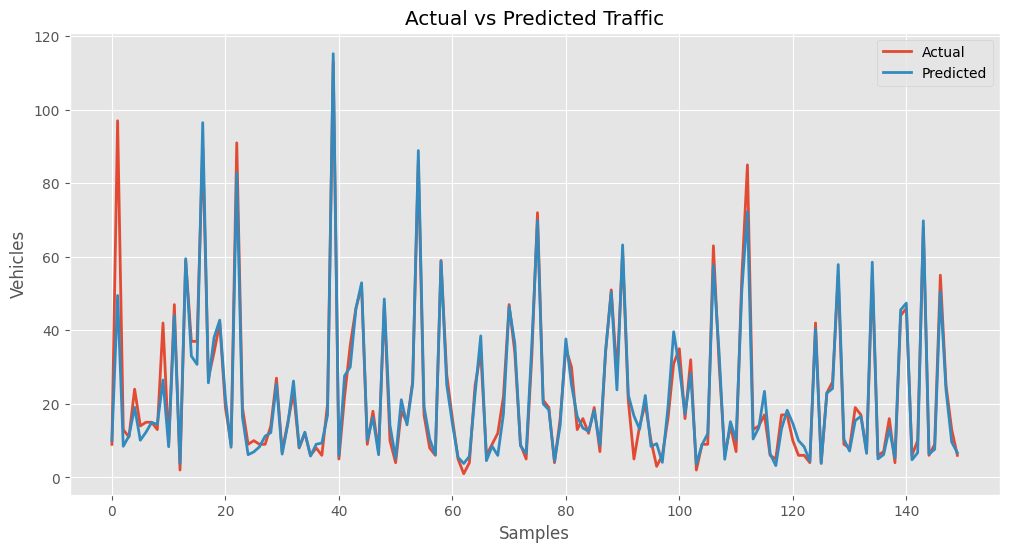

In [36]:
# ==========================================
# Actual vs Predicted
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:150],
    label="Actual",
    linewidth=2
)

plt.plot(
    rf_pred[:150],
    label="Predicted",
    linewidth=2
)

plt.legend()

plt.title("Actual vs Predicted Traffic")

plt.xlabel("Samples")

plt.ylabel("Vehicles")

plt.show()

In [37]:
# ==========================================
# Feature Importance
# ==========================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Junction,0.517047
1,Year,0.166750
4,Hour,0.143863
5,DayOfWeek,0.072439
2,Month,0.067716
3,Day,0.032184


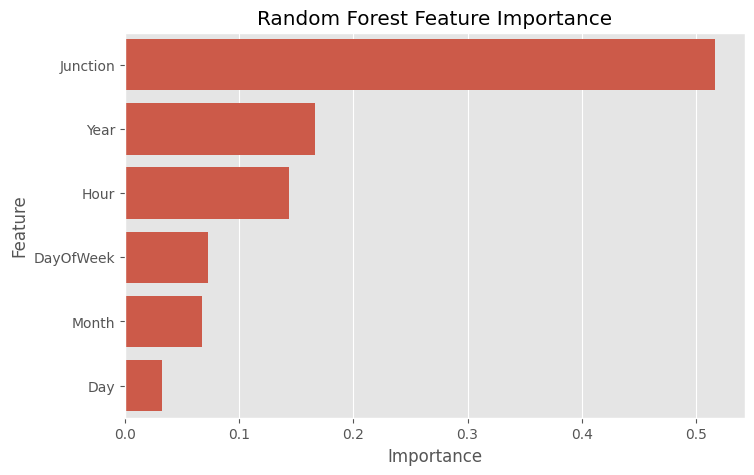

In [38]:
# ==========================================
# Feature Importance Graph
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()